In [ ]:
import pandas as pd
from google.colab import files

# 1. Abre a janela para você escolher o arquivo no seu computador
print("Por favor, selecione o arquivo 'fake_br_selecionado.csv' no seu computador:")
arquivos_enviados = files.upload()

# 2. Carrega o arquivo que você acabou de subir para a memória
df_selecionado = pd.read_csv('fake_br_selecionado.csv')

print("\nArquivo carregado com sucesso!")
print(f"Total de registros prontos para análise: {df_selecionado.shape}")


Por favor, selecione o arquivo 'fake_br_selecionado.csv' no seu computador:


Saving fake_br_selecionado.csv to fake_br_selecionado.csv

Arquivo carregado com sucesso!
Total de registros prontos para análise: (7200, 7)


In [ ]:
# Agrupa por categoria (Fake vs True) e mostra o resumo estatístico das colunas numéricas
df_selecionado.groupby('categoria')[['erros_gramaticais', 'num_palavras_capslock', 'pontuacao_excessiva']].describe().T


categoria                           Fake         True
erros_gramaticais     count  3600.000000  3600.000000
                      mean     31.210556   170.324444
                      std      22.627800   114.690079
                      min       1.000000     3.000000
                      25%      19.000000    95.000000
                      50%      27.000000   140.000000
                      75%      38.000000   219.000000
                      max     426.000000  1148.000000
num_palavras_capslock count  3600.000000  3600.000000
                      mean      3.708333    11.653056
                      std       5.111367    11.695992
                      min       0.000000     0.000000
                      25%       1.000000     5.000000
                      50%       3.000000     9.000000
                      75%       5.000000    15.000000
                      max     132.000000   233.000000
pontuacao_excessiva   count  3600.000000  3600.000000
                      mean      1.352500     6.773889
                      std       1.838709     6.501286
                      min       0.000000     0.000000
                      25%       0.000000     3.000000
                      50%       1.000000     5.000000
                      75%       2.000000     9.000000
                      max      35.000000    65.000000

In [ ]:
df_selecionado.groupby('categoria')[['erros_gramaticais', 'num_palavras_capslock', 'pontuacao_excessiva']].describe().T.round(2)

categoria                       Fake     True
erros_gramaticais     count  3600.00  3600.00
                      mean     31.21   170.32
                      std      22.63   114.69
                      min       1.00     3.00
                      25%      19.00    95.00
                      50%      27.00   140.00
                      75%      38.00   219.00
                      max     426.00  1148.00
num_palavras_capslock count  3600.00  3600.00
                      mean      3.71    11.65
                      std       5.11    11.70
                      min       0.00     0.00
                      25%       1.00     5.00
                      50%       3.00     9.00
                      75%       5.00    15.00
                      max     132.00   233.00
pontuacao_excessiva   count  3600.00  3600.00
                      mean      1.35     6.77
                      std       1.84     6.50
                      min       0.00     0.00
                      25%       0.00     3.00
                      50%       1.00     5.00
                      75%       2.00     9.00
                      max      35.00    65.00

In [ ]:
# Filtra automaticamente todas as colunas que são números e gera o resumo limpo
df_selecionado.groupby('categoria').describe(include=['number']).T.round(1)


categoria                      Fake    True
erros_gramaticais     count  3600.0  3600.0
                      mean     31.2   170.3
                      std      22.6   114.7
                      min       1.0     3.0
                      25%      19.0    95.0
                      50%      27.0   140.0
                      75%      38.0   219.0
                      max     426.0  1148.0
num_palavras_capslock count  3600.0  3600.0
                      mean      3.7    11.7
                      std       5.1    11.7
                      min       0.0     0.0
                      25%       1.0     5.0
                      50%       3.0     9.0
                      75%       5.0    15.0
                      max     132.0   233.0
pontuacao_excessiva   count  3600.0  3600.0
                      mean      1.4     6.8
                      std       1.8     6.5
                      min       0.0     0.0
                      25%       0.0     3.0
                      50%       1.0     5.0
                      75%       2.0     9.0
                      max      35.0    65.0

In [ ]:
df_selecionado.groupby('categoria').describe(include=['object']).T

categoria                     Fake      True
categoria_tema  count         3600      3600
                unique           6         6
                top       politica  politica
                freq          2090      2090
data_publicacao count         3600      3600
                unique         925      2814
                top     17/03/2016  4/1/2018
                freq            17        17
fontes          count         3600      3600
                unique           2         2
                top       Presente  Presente
                freq          3260      3525

/tmp/ipykernel_2764/2497410543.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_selecionado, x='categoria', palette=['#de425b', '#488f31'])


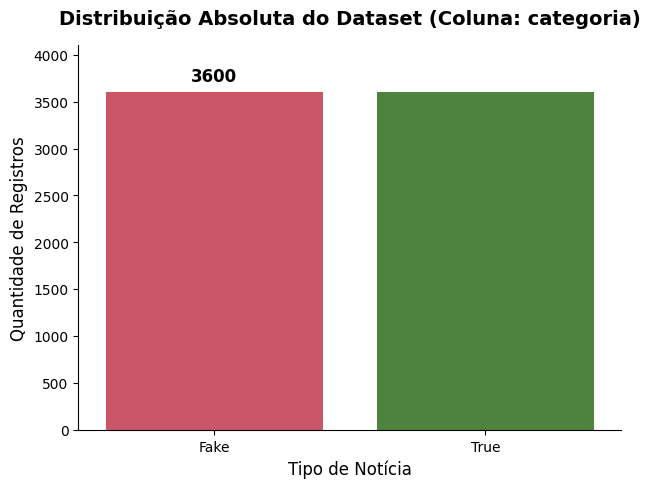

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define o tamanho da imagem do gráfico
plt.figure(figsize=(7, 5))

# 2. Cria o gráfico de barras e guarda a referência dele na variável 'ax'
ax = sns.countplot(data=df_selecionado, x='categoria', palette=['#de425b', '#488f31'])

# 3. Adiciona os números absolutos em cima de cada barra
ax.bar_label(ax.containers[0], fontsize=12, fontweight='bold', padding=5)

# 4. Adiciona títulos e rótulos profissionais
plt.title('Distribuição Absoluta do Dataset (Coluna: categoria)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Tipo de Notícia', fontsize=12)
plt.ylabel('Quantidade de Registros', fontsize=12)

# Ajusta o limite do eixo Y para o número não ficar colado no topo do gráfico
plt.ylim(0, 4100)

# 5. Remove as linhas da borda para limpar o visual
sns.despine()

# 6. Exibe o gráfico na tela
plt.show()


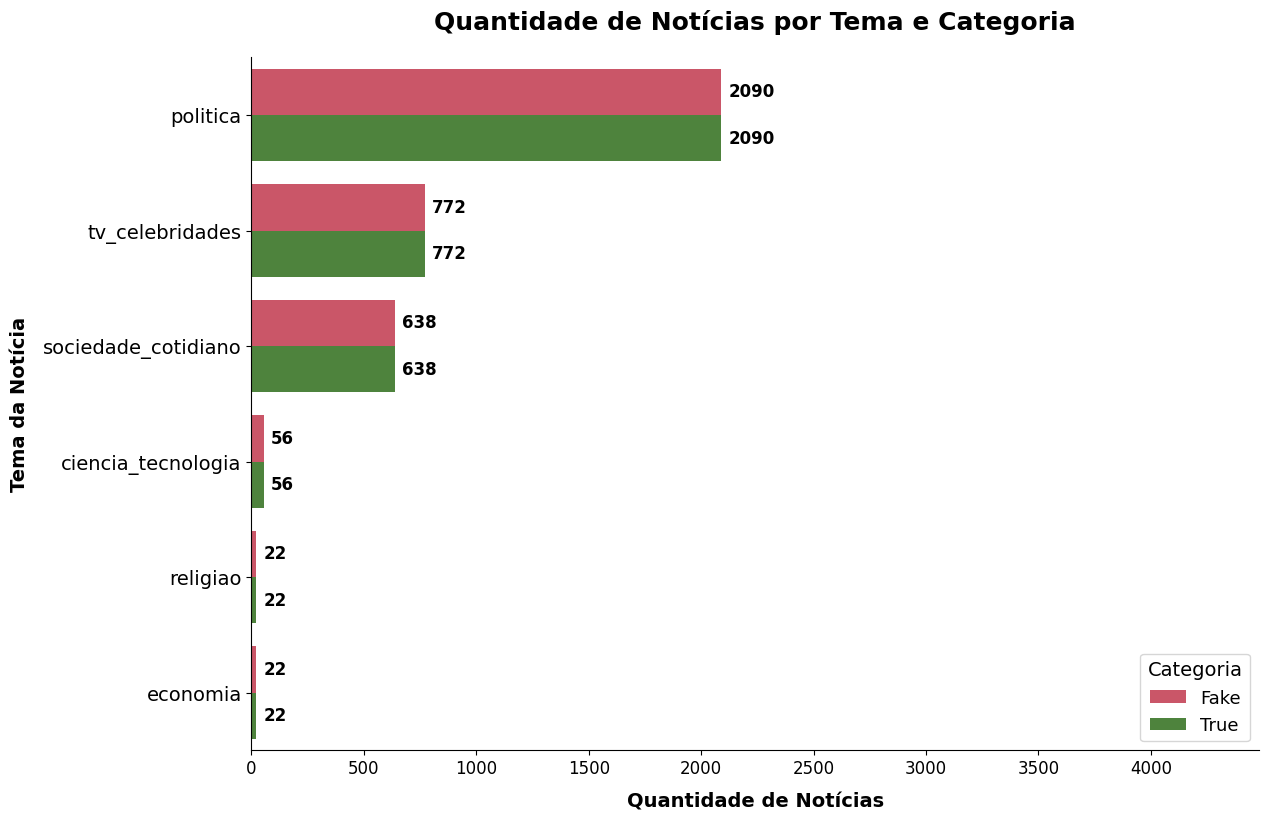

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Configura o tamanho da imagem do gráfico
plt.figure(figsize=(13, 9))

# 2. Cria o gráfico de barras horizontais
ax = sns.countplot(
    data=df_selecionado,
    y='categoria_tema',
    hue='categoria',
    palette=['#de425b', '#488f31'],
    order=df_selecionado['categoria_tema'].value_counts().index
)

# 3. Adiciona os números absolutos na ponta de cada barra (Aumentado para fontsize=12)
for container in ax.containers:
    ax.bar_label(container, fontsize=12, fontweight='bold', padding=5)

# 4. Configura os títulos principais com fontes grandes
plt.title('Quantidade de Notícias por Tema e Categoria', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Quantidade de Notícias', fontsize=14, fontweight='bold', labelpad=10)
plt.ylabel('Tema da Notícia', fontsize=14, fontweight='bold', labelpad=10)

# 5. AUMENTA A FONTE DAS CATEGORIAS NOS EIXOS (Nomes dos temas e números das escalas)
plt.yticks(fontsize=14)  # Aumenta o tamanho dos nomes dos temas (eixo Y)
plt.xticks(fontsize=12)  # Aumenta os números da escala de contagem (eixo X)

# 6. AUMENTA A FONTE DA LEGENDA (Fake vs True)
plt.legend(title='Categoria', title_fontsize=14, fontsize=13, loc='lower right')

# Alarga a borda direita para os números grandes não saírem da tela
plt.xlim(0, df_selecionado['categoria_tema'].value_counts().max() + 300)

# 7. Remove linhas desnecessárias da borda
sns.despine()

# 8. Exibe o gráfico
plt.show()


/tmp/ipykernel_5486/2857062692.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_temporal['ano'] = df_temporal['ano'].astype(int)


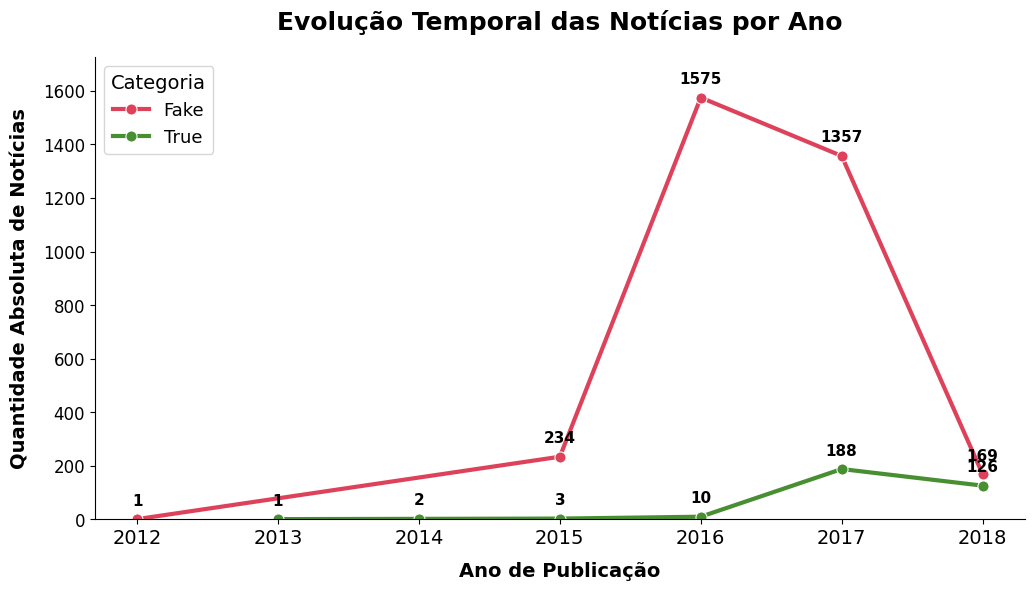

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Converte a coluna para o formato de Data do Python e extrai APENAS o ano
df_selecionado['ano'] = pd.to_datetime(df_selecionado['data_publicacao'], format='%d/%m/%Y', errors='coerce').dt.year

# Remove registros onde o ano não pôde ser identificado (evita erros no gráfico)
df_temporal = df_selecionado.dropna(subset=['ano'])

# Transforma os anos em números inteiros simples (tira o .0 do float)
df_temporal['ano'] = df_temporal['ano'].astype(int)

# 2. Agrupa os dados para contar quantas notícias existem por Ano e Categoria
df_contagem_tempo = df_temporal.groupby(['ano', 'categoria']).size().reset_index(name='total')

# 3. Configura o tamanho do gráfico
plt.figure(figsize=(12, 6))

# 4. Plota as linhas temporais (Vermelho para Fake, Verde para True)
ax = sns.lineplot(
    data=df_contagem_tempo,
    x='ano',
    y='total',
    hue='categoria',
    palette=['#de425b', '#488f31'],
    marker='o',          # Adiciona uma bolinha em cada ano
    markersize=8,        # Tamanho da bolinha
    linewidth=3          # Grossura da linha
)

# 5. Adiciona os NÚMEROS ABSOLUTOS em cima de cada bolinha do gráfico
for linha in ax.lines:
    xdata = linha.get_xdata()
    ydata = linha.get_ydata()
    for x, y in zip(xdata, ydata):
        if not pd.isna(y): # Garante que só escreve se houver dado
            ax.annotate(
                f'{int(y)}',
                (x, y),
                textcoords="offset points",
                xytext=(0, 10),
                ha='center',
                fontsize=11,
                fontweight='bold'
            )

# 6. Configura os títulos e aumenta as fontes das categorias
plt.title('Evolução Temporal das Notícias por Ano', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Ano de Publicação', fontsize=14, fontweight='bold', labelpad=10)
plt.ylabel('Quantidade Absoluta de Notícias', fontsize=14, fontweight='bold', labelpad=10)

# Aumenta a fonte dos anos no eixo X e dos valores no eixo Y
plt.xticks(df_contagem_tempo['ano'].unique(), fontsize=14)
plt.yticks(fontsize=12)

# Aumenta a fonte da Legenda
plt.legend(title='Categoria', title_fontsize=14, fontsize=13, loc='upper left')

# Dá um espaço extra no topo do gráfico para os números não sumirem
plt.ylim(0, df_contagem_tempo['total'].max() + 150)

# Remove as bordas desnecessárias
sns.despine()

# 7. Exibe o gráfico
plt.show()


/tmp/ipykernel_5486/3011422109.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_temporal['ano'] = df_temporal['ano'].astype(int)


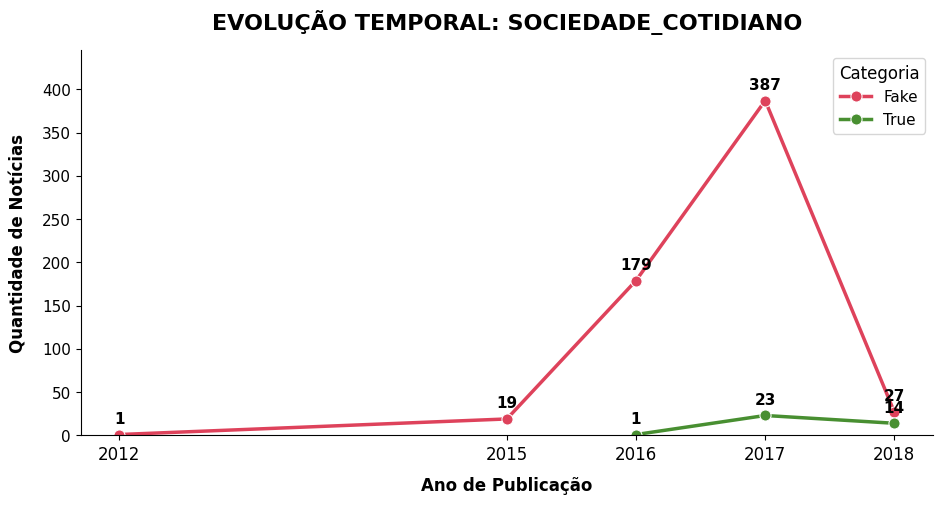

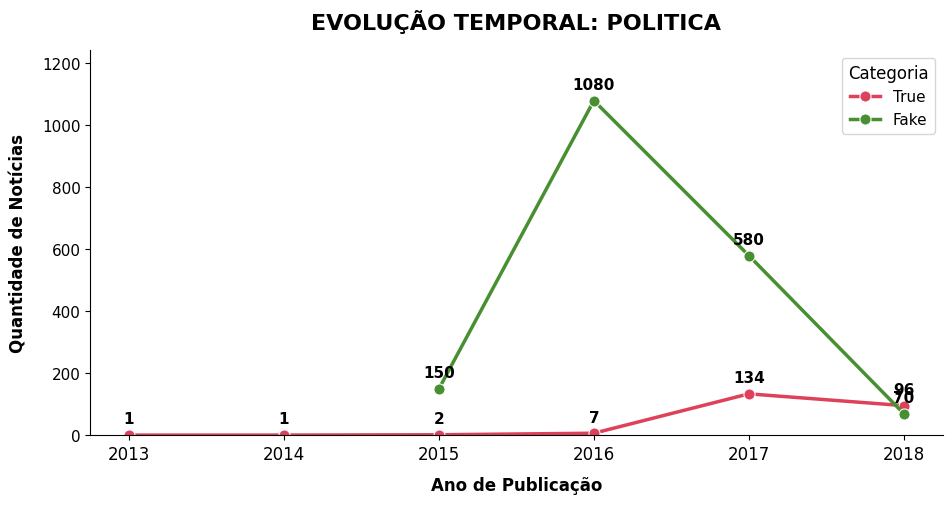

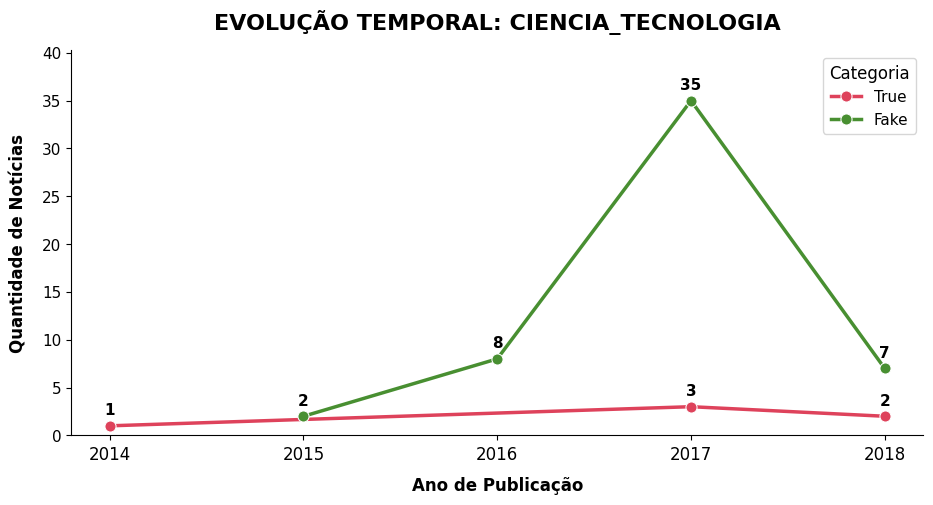

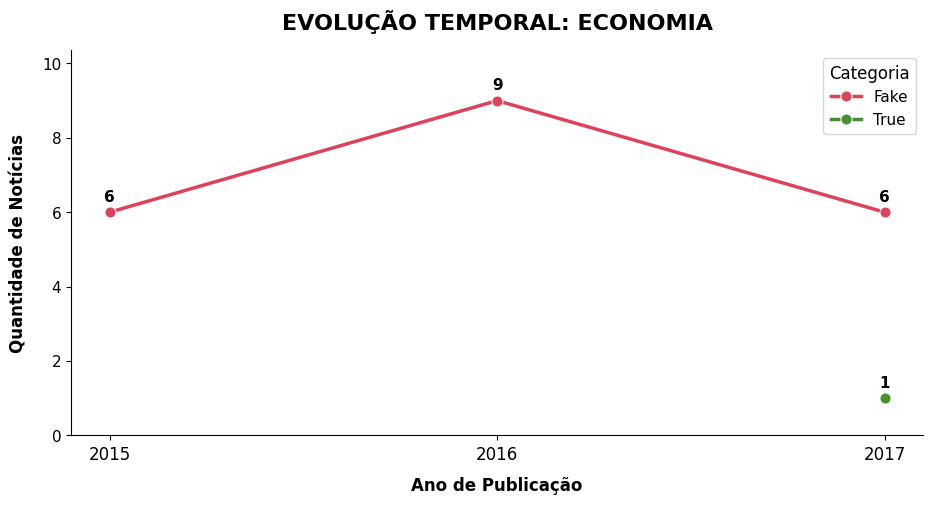

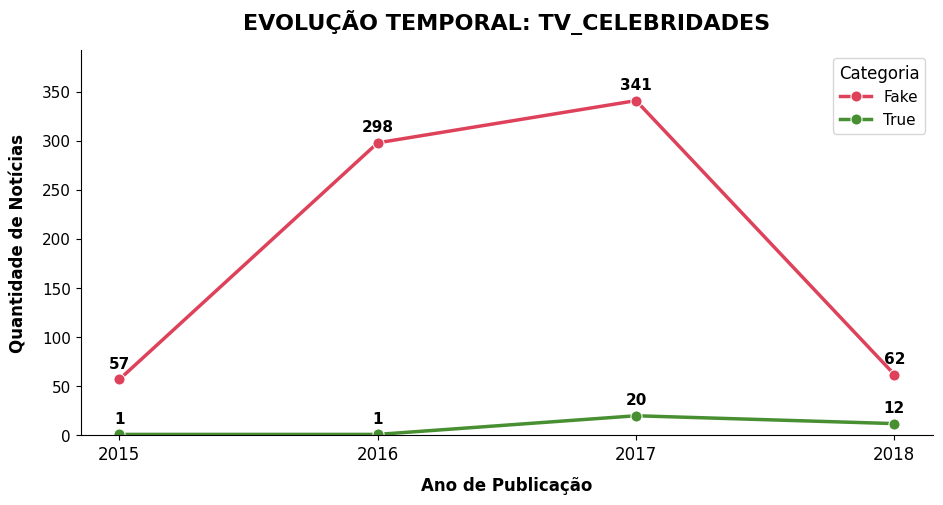

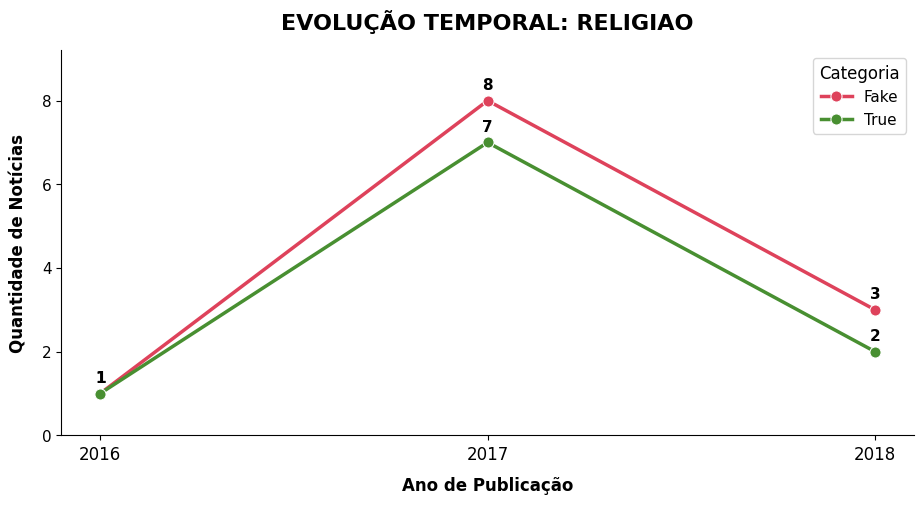

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Garante que a coluna de ano existe e está limpa
df_selecionado['ano'] = pd.to_datetime(df_selecionado['data_publicacao'], format='%d/%m/%Y', errors='coerce').dt.year
df_temporal = df_selecionado.dropna(subset=['ano', 'categoria_tema'])
df_temporal['ano'] = df_temporal['ano'].astype(int)

# 2. Agrupa contando as notícias por Ano, Tema e Categoria (Fake vs True)
df_agrupado = df_temporal.groupby(['ano', 'categoria_tema', 'categoria']).size().reset_index(name='total')

# 3. Descobre quais são os temas únicos presentes no dataset
temas_unicos = df_agrupado['categoria_tema'].unique()

# 4. Cria um gráfico separado e isolado para cada tema
for tema in temas_unicos:
    # Filtra os dados apenas para o tema atual da repetição
    df_tema_atual = df_agrupado[df_agrupado['categoria_tema'] == tema]

    # Configura o tamanho do gráfico atual
    plt.figure(figsize=(11, 5))

    # Desenha as linhas temporais (Vermelho para Fake, Verde para True)
    ax = sns.lineplot(
        data=df_tema_atual,
        x='ano',
        y='total',
        hue='categoria',
        palette=['#de425b', '#488f31'],
        marker='o',
        markersize=8,
        linewidth=2.5
    )

    # Adiciona os números absolutos em cima de cada bolinha deste gráfico
    for linha in ax.lines:
        xdata = linha.get_xdata()
        ydata = linha.get_ydata()
        for x, y in zip(xdata, ydata):
            if not pd.isna(y):
                ax.annotate(
                    f'{int(y)}',
                    (x, y),
                    textcoords="offset points",
                    xytext=(0, 8),
                    ha='center',
                    fontsize=11,
                    fontweight='bold'
                )

    # Configurações de títulos e fontes grandes para o tema atual
    plt.title(f'EVOLUÇÃO TEMPORAL: {tema.upper()}', fontsize=16, fontweight='bold', pad=15)
    plt.xlabel('Ano de Publicação', fontsize=12, fontweight='bold', labelpad=10)
    plt.ylabel('Quantidade de Notícias', fontsize=12, fontweight='bold', labelpad=10)

    # Configura as marcações dos anos no eixo X de forma limpa
    anos_do_tema = df_tema_atual['ano'].unique()
    plt.xticks(anos_do_tema, fontsize=12)
    plt.yticks(fontsize=11)

    # Configura a legenda
    plt.legend(title='Categoria', title_fontsize=12, fontsize=11, loc='upper right')

    # Dá um espaço extra no topo deste gráfico para o número não sumir na borda
    plt.ylim(0, df_tema_atual['total'].max() + (df_tema_atual['total'].max() * 0.15))

    # Remove as linhas da borda do gráfico atual
    sns.despine()

    # Força a exibição do gráfico atual de forma isolada antes de desenhar o próximo
    plt.show()


/tmp/ipykernel_5486/3701988385.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


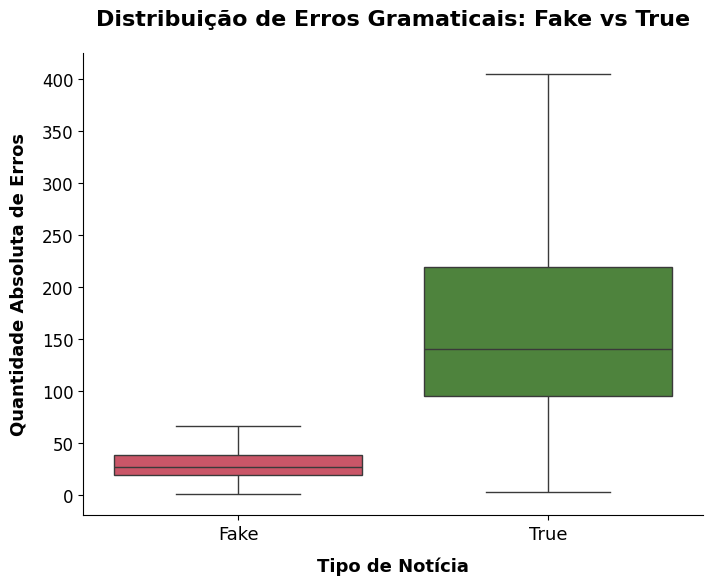

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Configura o tamanho da imagem do gráfico
plt.figure(figsize=(8, 6))

# 2. Cria o boxplot comparando os erros entre Fake e True
# Usamos o 'showfliers=False' para o gráfico não ficar achatado por causa de valores extremos
ax = sns.boxplot(
    data=df_selecionado,
    x='categoria',
    y='erros_gramaticais',
    palette=['#de425b', '#488f31'],
    showfliers=False
)

# 3. Configurações de títulos e aumento das fontes das categorias
plt.title('Distribuição de Erros Gramaticais: Fake vs True', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Tipo de Notícia', fontsize=13, fontweight='bold', labelpad=10)
plt.ylabel('Quantidade Absoluta de Erros', fontsize=13, fontweight='bold', labelpad=10)

# Aumenta a fonte dos textos dos eixos
plt.xticks(fontsize=13)
plt.yticks(fontsize=12)

# Remove as linhas desnecessárias da borda
sns.despine()

# 4. Mostra o gráfico na tela
plt.show()


/tmp/ipykernel_5486/729112713.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


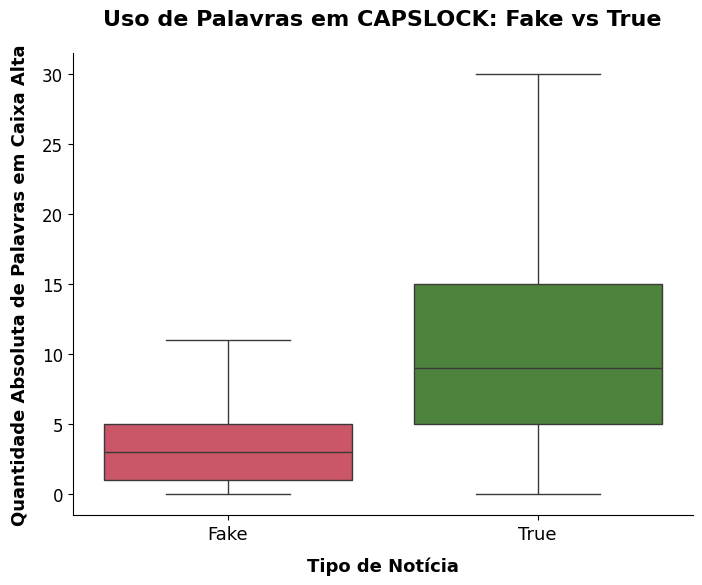

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Configura o tamanho da imagem do gráfico
plt.figure(figsize=(8, 6))

# 2. Cria o boxplot comparando o Caps Lock entre Fake e True
# Mantemos o 'showfliers=False' para esconder valores extremos que distorcem o visual
ax = sns.boxplot(
    data=df_selecionado,
    x='categoria',
    y='num_palavras_capslock',
    palette=['#de425b', '#488f31'],
    showfliers=False
)

# 3. Configurações de títulos e aumento das fontes das categorias
plt.title('Uso de Palavras em CAPSLOCK: Fake vs True', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Tipo de Notícia', fontsize=13, fontweight='bold', labelpad=10)
plt.ylabel('Quantidade Absoluta de Palavras em Caixa Alta', fontsize=13, fontweight='bold', labelpad=10)

# Aumenta a fonte dos textos das escalas e categorias
plt.xticks(fontsize=13)
plt.yticks(fontsize=12)

# Remove as linhas da borda
sns.despine()

# 4. Mostra o gráfico na tela
plt.show()


/tmp/ipykernel_5486/2242306906.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


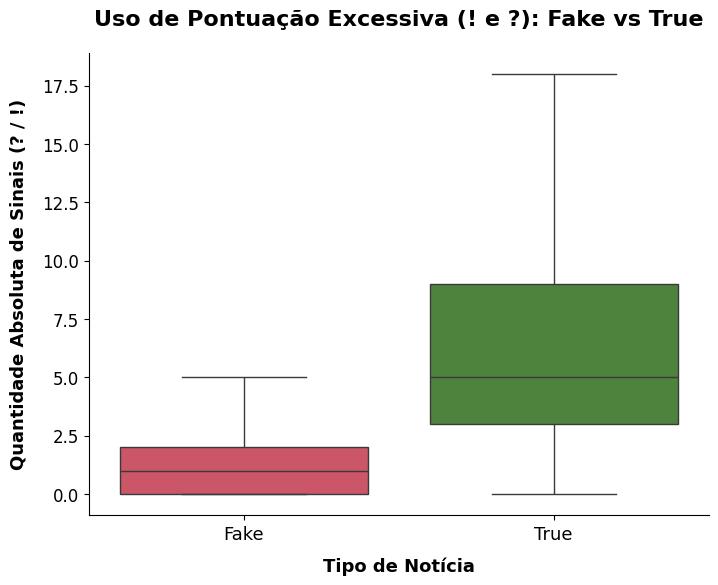

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Configura o tamanho da imagem do gráfico
plt.figure(figsize=(8, 6))

# 2. Cria o boxplot comparando a pontuação excessiva entre Fake e True
ax = sns.boxplot(
    data=df_selecionado,
    x='categoria',
    y='pontuacao_excessiva',
    palette=['#de425b', '#488f31'],
    showfliers=False
)

# 3. Configurações de títulos e aumento das fontes das categorias
plt.title('Uso de Pontuação Excessiva (! e ?): Fake vs True', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Tipo de Notícia', fontsize=13, fontweight='bold', labelpad=10)
plt.ylabel('Quantidade Absoluta de Sinais (? / !)', fontsize=13, fontweight='bold', labelpad=10)

# Aumenta a fonte dos textos das escalas e categorias
plt.xticks(fontsize=13)
plt.yticks(fontsize=12)

# Remove as linhas da borda
sns.despine()

# 4. Mostra o gráfico na tela
plt.show()


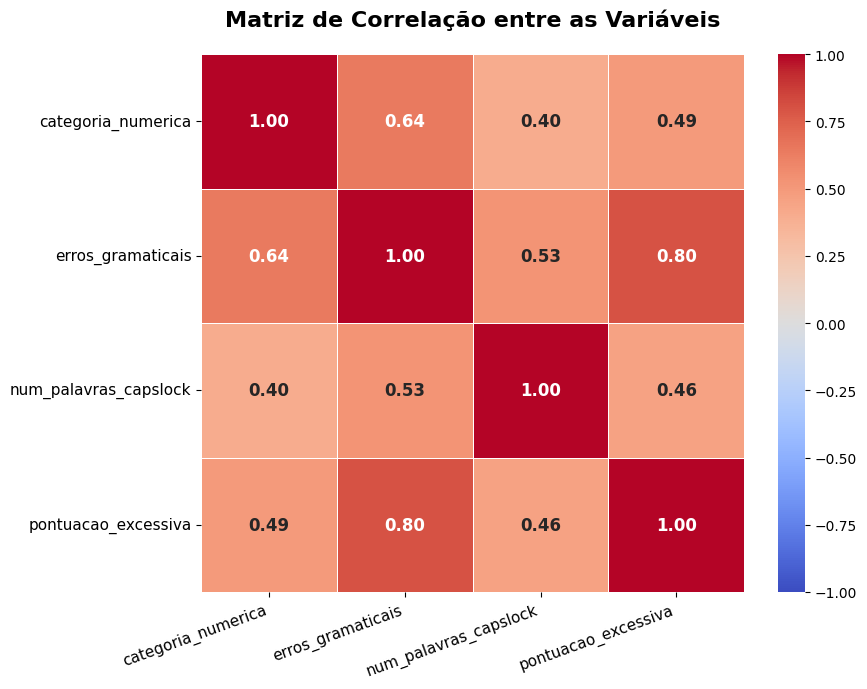

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Cria uma cópia dos dados para não alterar o seu DataFrame original
df_correlacao = df_selecionado.copy()

# 2. Transforma a coluna 'categoria' em número para o cálculo da correlação
# Fake vira 0 e True vira 1
df_correlacao['categoria_numerica'] = df_correlacao['categoria'].map({'Fake': 0, 'True': 1})

# 3. Seleciona apenas as colunas numéricas que queremos analisar
colunas_num = ['categoria_numerica', 'erros_gramaticais', 'num_palavras_capslock', 'pontuacao_excessiva']
matriz = df_correlacao[colunas_num].corr()

# 4. Configura o tamanho da imagem do gráfico
plt.figure(figsize=(9, 7))

# 5. Desenha o mapa de calor (Heatmap)
# annot=True coloca os valores numéricos dentro dos quadrados
sns.heatmap(
    matriz,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5,
    vmax=1,
    vmin=-1,
    annot_kws={"size": 12, "weight": "bold"} # Aumenta a fonte dos números internos
)

# 6. Configura os títulos e aumenta as fontes das categorias nos eixos
plt.title('Matriz de Correlação entre as Variáveis', fontsize=16, fontweight='bold', pad=20)

# Aumenta o tamanho dos textos das variáveis nos eixos X e Y
plt.xticks(fontsize=11, rotation=20, ha='right')
plt.yticks(fontsize=11)

# Ajusta o espaçamento para os nomes não cortarem na tela
plt.tight_layout()

# 7. Exibe o gráfico na tela
plt.show()


In [ ]:
import os
import io
import zipfile
import urllib.request
import pandas as pd
from IPython.display import display
from google.colab import data_table
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# 1. Download do repositório Fake.br
zip_url = "https://codeload.github.com/roneysco/Fake.br-Corpus/zip/refs/heads/master"
print("Baixando o dataset...")
req = urllib.request.Request(zip_url, headers={'User-Agent': 'Mozilla/5.0'})

try:
    with urllib.request.urlopen(req) as response:
        zip_buffer = io.BytesIO(response.read())
        with zipfile.ZipFile(zip_buffer, 'r') as zip_ref:
            zip_ref.extractall('.')
    print("Download concluído com sucesso!\n")
except Exception as e:
    print(f"Erro ao baixar o arquivo: {e}")

fake_path = 'Fake.br-Corpus-master/full_texts/fake'
true_path = 'Fake.br-Corpus-master/full_texts/true'
fake_meta_path = 'Fake.br-Corpus-master/full_texts/fake-meta-information'
true_meta_path = 'Fake.br-Corpus-master/full_texts/true-meta-information'

dados = []

# Nova função adaptada para ler as 24 features nativas do meta-information
def ler_24_metadados(caminho_meta):
    """Lê as 24 linhas de metadados estruturados do Fake.br-Corpus."""
    # Lista com os nomes exatos das 24 features do dataset
    nomes_features = [
        'meta_author', 'meta_link', 'meta_category', 'meta_date_pub',
        'meta_tokens', 'meta_words_no_punctuation', 'meta_types',
        'meta_links_inside', 'meta_words_uppercase', 'meta_verbs',
        'meta_subjunctive_imperative_verbs', 'meta_nouns', 'meta_adjectives',
        'meta_adverbs', 'meta_pronouns', 'meta_stopwords',
        'meta_expressiveness_emotiveness', 'meta_diversity_ttr',
        'meta_spelling_errors', 'meta_emotiveness_ratio',
        'meta_interrogative_sentences', 'meta_exclamatory_sentences',
        'meta_subordinate_sentences', 'meta_vocabulary_richness'
    ]

    # Dicionário padrão caso o arquivo não exista
    meta_dict = {nome: "N/A" for nome in nomes_features}

    if os.path.exists(caminho_meta):
        with open(caminho_meta, 'r', encoding='utf-8', errors='ignore') as f:
            linhas = [l.strip() for l in f.readlines()]

        # Preenche o dicionário respeitando o limite de linhas existentes
        for i in range(min(len(linhas), 24)):
            meta_dict[nomes_features[i]] = linhas[i]

    return meta_dict

# Funções para extração de trechos adicionais (suas funções customizadas)
def verificar_fontes(texto):
    texto_lower = texto.lower()
    termos_fonte = ["fonte", "segundo", "especialista", "pesquisa", "estudo", "afirmou", "de acordo", "g1", "r7", "uol"]
    tem_aspas = '"' in texto or '“' in texto or '”' in texto
    tem_citacao = any(termo in texto_lower for termo in termos_fonte)
    return "Presente" if (tem_aspas or tem_citacao) else "Ausente"

def identificar_nome_fonte(texto):
    texto_lower = texto.lower()
    veiculos = ["g1", "r7", "uol", "folha", "estadao", "bbc", "reuters", "agencia brasil", "diario oficial", "aneel"]
    for v in veiculos:
        if v in texto_lower:
            return v.upper()
    termos = ["segundo", "especialista", "pesquisa", "estudo", "afirmou", "de acordo"]
    if any(termo in texto_lower for termo in termos) or ('"' in texto or '“' in texto):
        return "Citação/Aspas sem nome"
    return "Nenhuma fonte declarada"

def extrair_termos_sensacionalistas(texto):
    texto_lower = texto.lower()
    gatilhos = ["urgente", "bomba", "chocante", "surpreendente", "milagroso", "segredo", "inacreditável", "revelado", "compartilhe", "absurdo", "polêmica", "denúncia"]
    encontrados = [palavra for palavra in gatilhos if palavra in texto_lower]
    return ", ".join(encontrados) if encontrados else "Nenhum termo encontrado"

def extrair_frases_emotivas(texto):
    import re
    frases = re.findall(r'[^.!?]*[!?]', texto)
    if frases:
        trechos = [f.strip() for f in frases[:3]]
        return " | ".join(trechos)
    return "Sem pontuação emotiva"

# 2. Carregando amostra de 10 notícias falsas e 10 verdadeiras
for arquivo in sorted(os.listdir(fake_path))[:10]:
    caminho = os.path.join(fake_path, arquivo)
    if os.path.isfile(caminho) and arquivo.endswith('.txt'):
        nome_meta = arquivo.replace('.txt', '-meta.txt')
        caminho_meta = os.path.join(fake_meta_path, nome_meta)

        # Obtém o dicionário com as 24 features nativas
        dict_metadados = ler_24_metadados(caminho_meta)

        with open(caminho, 'r', encoding='utf-8', errors='ignore') as f:
            conteudo = f.read()

        # Cria a estrutura base do registro
        registro = {
            'texto': conteudo,
            'categoria': 'Fake',
            'label': 0,
            'fontes': verificar_fontes(conteudo),
            'fonte_identificada': identificar_nome_fonte(conteudo),
            'sensacionalismo': conteudo.lower().count("urgente") + conteudo.lower().count("bomba") + conteudo.lower().count("chocante") + conteudo.lower().count("segredo"),
            'quais_termo_sensacionalistas': extrair_termos_sensacionalistas(conteudo),
            'pontuacao_emotiva': conteudo.count('!') + conteudo.count('?'),
            'quais_frases_emotivas': extrair_frases_emotivas(conteudo)
        }
        # Mescla (combina) as 24 features lidas no registro
        registro.update(dict_metadados)
        dados.append(registro)

for arquivo in sorted(os.listdir(true_path))[:10]:
    caminho = os.path.join(true_path, arquivo)
    if os.path.isfile(caminho) and arquivo.endswith('.txt'):
        nome_meta = arquivo.replace('.txt', '-meta.txt')
        caminho_meta = os.path.join(true_meta_path, nome_meta)

        dict_metadados = ler_24_metadados(caminho_meta)

        with open(caminho, 'r', encoding='utf-8', errors='ignore') as f:
            conteudo = f.read()

        registro = {
            'texto': conteudo,
            'categoria': 'True',
            'label': 1,
            'fontes': verificar_fontes(conteudo),
            'fonte_identificada': identificar_nome_fonte(conteudo),
            'sensacionalismo': conteudo.lower().count("urgente") + conteudo.lower().count("bomba") + conteudo.lower().count("chocante") + conteudo.lower().count("segredo"),
            'quais_termo_sensacionalistas': extrair_termos_sensacionalistas(conteudo),
            'pontuacao_emotiva': conteudo.count('!') + conteudo.count('?'),
            'quais_frases_emotivas': extrair_frases_emotivas(conteudo)
        }
        registro.update(dict_metadados)
        dados.append(registro)

df_amostra = pd.DataFrame(dados)

# 3. Treinamento da IA
vectorizer = TfidfVectorizer(max_features=1000)
X_tfidf = vectorizer.fit_transform(df_amostra['texto'])
modelo = LogisticRegression()
modelo.fit(X_tfidf, df_amostra['label'])
probabilidades = modelo.predict_proba(X_tfidf)

df_amostra['porcentagem_verdade'] = [f"{round(p[1] * 100, 1)}%" for p in probabilidades]
df_amostra['porcentagem_fake'] = [f"{round(p[0] * 100, 1)}%" for p in probabilidades]

# 4. Organizando a ordem de exibição das colunas de forma limpa
colunas_ordenadas = [
    'texto', 'categoria', 'porcentagem_verdade', 'porcentagem_fake',
    'meta_author', 'meta_link', 'meta_category', 'meta_date_pub',
    'meta_tokens', 'meta_words_no_punctuation', 'meta_types', 'meta_links_inside',
    'meta_words_uppercase', 'meta_verbs', 'meta_subjunctive_imperative_verbs',
    'meta_nouns', 'meta_adjectives', 'meta_adverbs', 'meta_pronouns', 'meta_stopwords',
    'meta_expressiveness_emotiveness', 'meta_diversity_ttr', 'meta_spelling_errors',
    'meta_emotiveness_ratio', 'meta_interrogative_sentences', 'meta_exclamatory_sentences',
    'meta_subordinate_sentences', 'meta_vocabulary_richness',
    'fontes', 'fonte_identificada', 'sensacionalismo', 'quais_termo_sensacionalistas',
    'pontuacao_emotiva', 'quais_frases_emotivas'
]

df_amostra = df_amostra[colunas_ordenadas]

# Exibição da tabela interativa no Colab
data_table.enable_dataframe_formatter()
display(df_amostra)


Baixando o dataset...
Download concluído com sucesso!



,texto,categoria,porcentagem_verdade,porcentagem_fake,meta_author,meta_link,meta_category,meta_date_pub,meta_tokens,meta_words_no_punctuation,...,meta_interrogative_sentences,meta_exclamatory_sentences,meta_subordinate_sentences,meta_vocabulary_richness,fontes,fonte_identificada,sensacionalismo,quais_termo_sensacionalistas,pontuacao_emotiva,quais_frases_emotivas
0,Kátia Abreu diz que vai colocar sua expulsão e...,Fake,39.7%,60.3%,mrk,https://ceticismopolitico.com/2017/11/30/katia...,politica,2017-11-30,211,185,...,14.2308,4.40541,0.0,0.263158,Presente,Citação/Aspas sem nome,0,Nenhum termo encontrado,1,"Ué, mas se a expulsão é algo tão bom para seu ..."
1,"Dr. Ray peita Bolsonaro, chama-o de conservad...",Fake,44.9%,55.1%,None,https://ceticismopolitico.com/2017/11/24/dr-ra...,politica,2017-11-24,289,254,...,18.1429,4.74409,0.00787402,0.241667,Presente,Citação/Aspas sem nome,0,Nenhum termo encontrado,1,Rey espinafrando Bolsonaro: Quem dá brechas nã...
2,Reinaldo Azevedo desmascarado pela Polícia Fed...,Fake,45.0%,55.0%,None,https://afolhabrasil.com.br/politica/reinaldo-...,politica,2017-05-23,304,275,...,17.1875,4.88727,0.00363636,0.12782,Presente,Nenhuma fonte declarada,0,Nenhum termo encontrado,0,Sem pontuação emotiva
3,Relatório assustador do BNDES mostra dinheiro ...,Fake,48.0%,52.0%,None,https://www.diariodobrasil.org/relatorio-assus...,politica,24/07/2017,639,572,...,22.88,5.45804,0.00174825,0.229008,Presente,Citação/Aspas sem nome,1,urgente,0,Sem pontuação emotiva
4,"Radialista americano fala sobre o PT: ""Eles ve...",Fake,37.8%,62.2%,None,https://www.diariodobrasil.org/radialista-amer...,politica,25/07/2017,128,111,...,5.84211,4.63964,0.0,0.269231,Presente,Citação/Aspas sem nome,0,Nenhum termo encontrado,1,como deixaram a microcefalia crescer nesse país?
5,Willian Waack continuará internado no Sírio Li...,Fake,36.2%,63.8%,None,https://www.diariodobrasil.org/situacao-de-waa...,tv_celebridades,25/07/2017,103,93,...,11.625,5.48387,0.0107527,0.268293,Ausente,Nenhuma fonte declarada,0,Nenhum termo encontrado,0,Sem pontuação emotiva
6,Problema cardíaco tira William Waack do Jornal...,Fake,39.3%,60.7%,None,https://www.diariodobrasil.org/problema-cardia...,sociedade_cotidiano,21/07/2017,109,96,...,8.72727,5.26042,0.0,0.302326,Ausente,Nenhuma fonte declarada,0,Nenhum termo encontrado,0,Sem pontuação emotiva
7,Edir Macedo poderá disputar as eleições presid...,Fake,43.3%,56.7%,None,https://www.diariodobrasil.org/edir-macedo-pod...,politica,20/07/2017,242,209,...,16.0769,5.13876,0.0,0.397727,Presente,Citação/Aspas sem nome,0,Nenhum termo encontrado,0,Sem pontuação emotiva
8,"Boechat sobre Lula: ""Sua ALMA pode ser honesta...",Fake,38.1%,61.9%,None,https://www.diariodobrasil.org/boechat-sobre-l...,politica,21/07/2017,105,79,...,4.38889,4.08861,0.0,0.216216,Presente,Citação/Aspas sem nome,0,Nenhum termo encontrado,0,Sem pontuação emotiva
9,PT diz que Lula não tem dinheiro para sobreviv...,Fake,46.4%,53.6%,None,https://www.diariodobrasil.org/pt-diz-que-lula...,politica,20/07/2017,207,188,...,23.5,4.53191,0.0,0.25,Presente,Citação/Aspas sem nome,1,segredo,0,Sem pontuação emotiva


In [ ]:

print(list(df_amostra))


['texto', 'categoria', 'porcentagem_verdade', 'porcentagem_fake', 'meta_author', 'meta_link', 'meta_category', 'meta_date_pub', 'meta_tokens', 'meta_words_no_punctuation', 'meta_types', 'meta_links_inside', 'meta_words_uppercase', 'meta_verbs', 'meta_subjunctive_imperative_verbs', 'meta_nouns', 'meta_adjectives', 'meta_adverbs', 'meta_pronouns', 'meta_stopwords', 'meta_expressiveness_emotiveness', 'meta_diversity_ttr', 'meta_spelling_errors', 'meta_emotiveness_ratio', 'meta_interrogative_sentences', 'meta_exclamatory_sentences', 'meta_subordinate_sentences', 'meta_vocabulary_richness', 'fontes', 'fonte_identificada', 'sensacionalismo', 'quais_termo_sensacionalistas', 'pontuacao_emotiva', 'quais_frases_emotivas']


In [ ]:
df_amostra.to_csv('noticias_fake_br_24features.csv', index=False, encoding='utf-8-sig')


from google.colab import files
files.download('noticias_fake_br_24features.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

/tmp/ipykernel_1284/1699615863.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


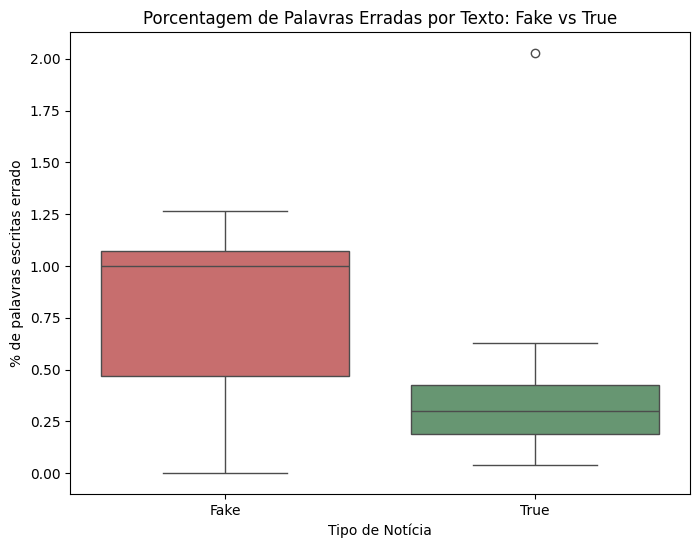

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

df_amostra['meta_spelling_errors'] = df_amostra['meta_spelling_errors'].astype(float).astype(int)
df_amostra['meta_words_no_punctuation'] = df_amostra['meta_words_no_punctuation'].astype(float).astype(int)

df_amostra['porcentagem_palavras_erradas'] = (
    df_amostra['meta_spelling_errors'] / df_amostra['meta_words_no_punctuation']
) * 100


plt.figure(figsize=(8, 6))
sns.boxplot(
    data=df_amostra,
    x='categoria',
    y='porcentagem_palavras_erradas',
    palette={'Fake': '#d65f5f', 'True': '#5f9e6e'}
)


plt.title('Porcentagem de Palavras Erradas por Texto: Fake vs True')
plt.xlabel('Tipo de Notícia')
plt.ylabel('% de palavras escritas errado')
plt.show()





/tmp/ipykernel_1284/971075643.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


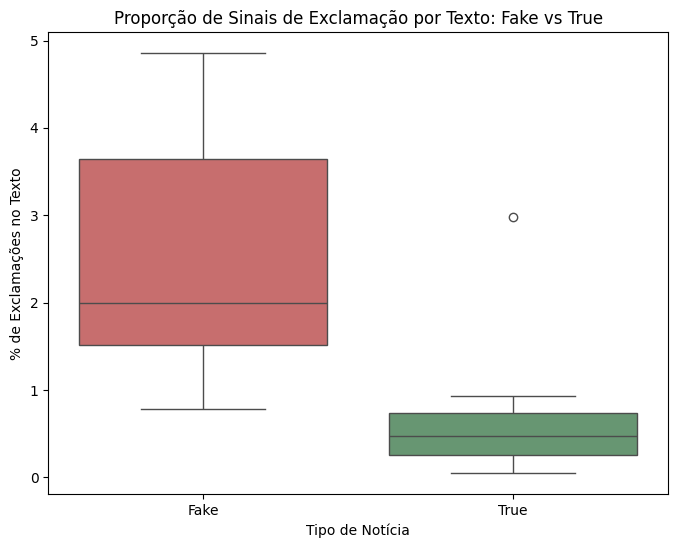

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Converte as colunas de pontuação e tamanho para número decimal (float) e depois inteiro (int)
df_amostra['meta_exclamatory_sentences'] = df_amostra['meta_exclamatory_sentences'].astype(float).astype(int)
df_amostra['meta_tokens'] = df_amostra['meta_tokens'].astype(float).astype(int)

# 2. Calcula a porcentagem de pontuações exclamativas em relação ao total de elementos (tokens) do texto
df_amostra['porcentagem_exclamacoes'] = (
    df_amostra['meta_exclamatory_sentences'] / df_amostra['meta_tokens']
) * 100

# 3. Desenha o gráfico de boxplot proporcional para pontuação
plt.figure(figsize=(8, 6))
sns.boxplot(
    data=df_amostra,
    x='categoria',
    y='porcentagem_exclamacoes',
    palette={'Fake': '#d65f5f', 'True': '#5f9e6e'}
)

# Configurações visuais do gráfico
plt.title('Proporção de Sinais de Exclamação por Texto: Fake vs True')
plt.xlabel('Tipo de Notícia')
plt.ylabel('% de Exclamações no Texto')
plt.show()


In [ ]:
print(df_amostra.columns)

Index(['texto', 'categoria', 'porcentagem_verdade', 'porcentagem_fake',
       'meta_author', 'meta_link', 'meta_category', 'meta_date_pub',
       'meta_tokens', 'meta_words_no_punctuation', 'meta_types',
       'meta_links_inside', 'meta_words_uppercase', 'meta_verbs',
       'meta_subjunctive_imperative_verbs', 'meta_nouns', 'meta_adjectives',
       'meta_adverbs', 'meta_pronouns', 'meta_stopwords',
       'meta_expressiveness_emotiveness', 'meta_diversity_ttr',
       'meta_spelling_errors', 'meta_emotiveness_ratio',
       'meta_interrogative_sentences', 'meta_exclamatory_sentences',
       'meta_subordinate_sentences', 'meta_vocabulary_richness', 'fontes',
       'fonte_identificada', 'sensacionalismo', 'quais_termo_sensacionalistas',
       'pontuacao_emotiva', 'quais_frases_emotivas',
       'porcentagem_palavras_erradas'],
      dtype='object')


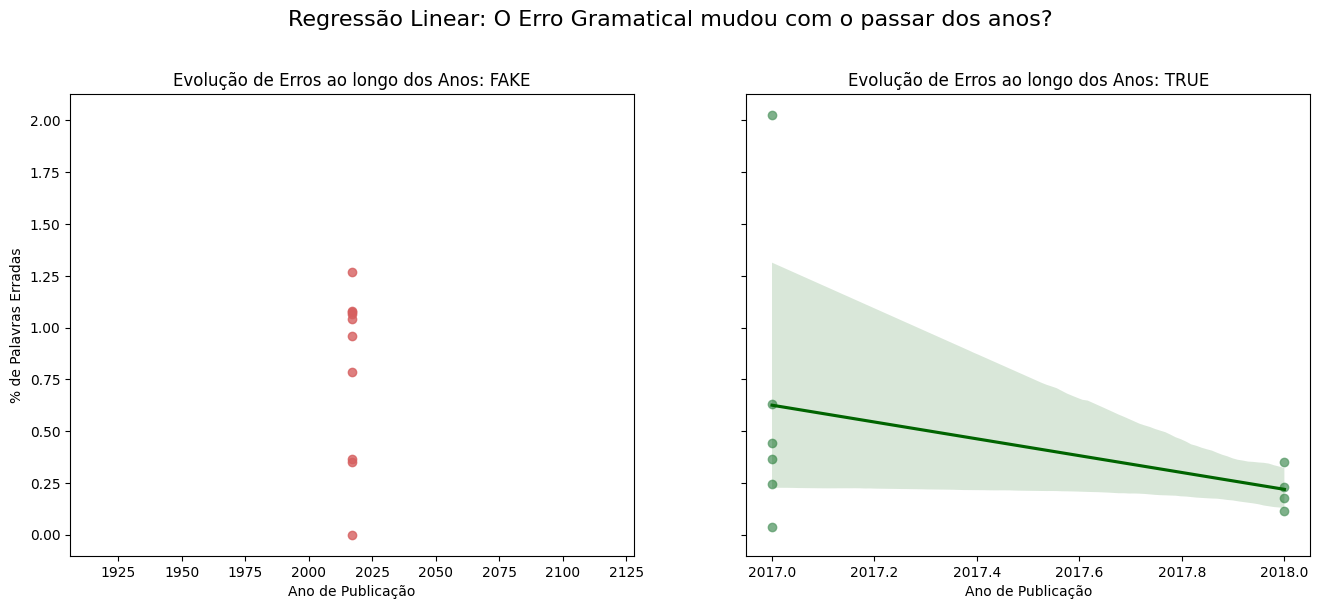

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# 1. Limpeza: Extrai apenas os 4 algarismos do ano da coluna meta_date_pub
# O comando re.extract(r'(\d{4})') busca uma sequência de 4 números no texto (ex: 2017, 2018)
df_amostra['ano'] = df_amostra['meta_date_pub'].str.extract(r'(\d{4})').astype(float)

# Remove linhas onde o ano não foi encontrado (caso o metadado esteja vazio/NA)
df_limpo = df_amostra.dropna(subset=['ano']).copy()

# 2. Configura a tela para mostrar dois gráficos lado a lado
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Gráfico 1: Tendência dos erros nas Notícias Falsas (Fake)
df_fake = df_limpo[df_limpo['categoria'] == 'Fake']
sns.regplot(
    data=df_fake, x='ano', y='porcentagem_palavras_erradas',
    ax=axes[0], color='#d65f5f', line_kws={'color': 'darkred'}
)
axes[0].set_title('Evolução de Erros ao longo dos Anos: FAKE')
axes[0].set_xlabel('Ano de Publicação')
axes[0].set_ylabel('% de Palavras Erradas')

# Gráfico 2: Tendência dos erros nas Notícias Verdadeiras (True)
df_true = df_limpo[df_limpo['categoria'] == 'True']
sns.regplot(
    data=df_true, x='ano', y='porcentagem_palavras_erradas',
    ax=axes[1], color='#5f9e6e', line_kws={'color': 'darkgreen'}
)
axes[1].set_title('Evolução de Erros ao longo dos Anos: TRUE')
axes[1].set_xlabel('Ano de Publicação')
axes[1].set_ylabel('') # Oculta o label repetido

plt.suptitle('Regressão Linear: O Erro Gramatical mudou com o passar dos anos?', fontsize=16, y=1.02)
plt.show()


In [ ]:
import pandas as pd
from google.colab import files

print("selecione o arquivo")
arquivos_enviados = files.upload()


df_selecionado = pd.read_csv('noticias_fake_br_24features.csv')

print("\nArquivo carregado com sucesso!")
print(f"Total de registros prontos para análise: {df_selecionado.shape}")


selecione o arquivo


Saving noticias_fake_br_24features.csv to noticias_fake_br_24features.csv

Arquivo carregado com sucesso!
Total de registros prontos para análise: (20, 34)


In [ ]:
print(df_selecionado.columns)

Index(['texto', 'categoria', 'porcentagem_verdade', 'porcentagem_fake',
       'meta_author', 'meta_link', 'meta_category', 'meta_date_pub',
       'meta_tokens', 'meta_words_no_punctuation', 'meta_types',
       'meta_links_inside', 'meta_words_uppercase', 'meta_verbs',
       'meta_subjunctive_imperative_verbs', 'meta_nouns', 'meta_adjectives',
       'meta_adverbs', 'meta_pronouns', 'meta_stopwords',
       'meta_expressiveness_emotiveness', 'meta_diversity_ttr',
       'meta_spelling_errors', 'meta_emotiveness_ratio',
       'meta_interrogative_sentences', 'meta_exclamatory_sentences',
       'meta_subordinate_sentences', 'meta_vocabulary_richness', 'fontes',
       'fonte_identificada', 'sensacionalismo', 'quais_termo_sensacionalistas',
       'pontuacao_emotiva', 'quais_frases_emotivas'],
      dtype='object')


In [ ]:
print(df_selecionado.porcentagem_verdade)

0     39.7%
1     44.9%
2     45.0%
3     48.0%
4     37.8%
5     36.2%
6     39.3%
7     43.3%
8     38.1%
9     46.4%
10    57.6%
11    58.0%
12    56.1%
13    60.6%
14    58.7%
15    60.0%
16    57.3%
17    57.6%
18    57.0%
19    58.4%
Name: porcentagem_verdade, dtype: object


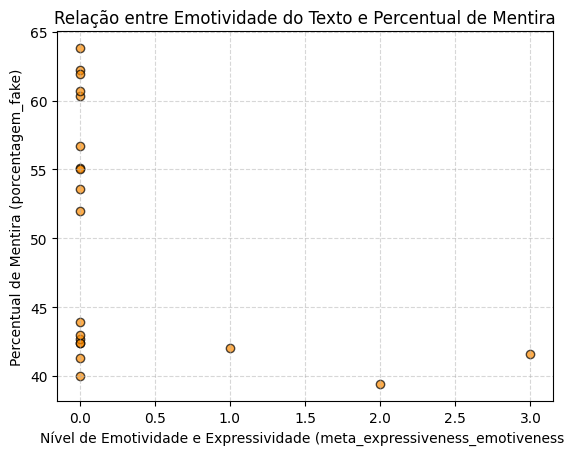

In [ ]:
import matplotlib.pyplot as plt

# 1. Garantir que as duas colunas sejam números (limpando o '%' se houver)
# Se a sua coluna 'meta_expressiveness_emotiveness' já for número puro, não precisa do .str.replace
expressividade = df_selecionado['meta_expressiveness_emotiveness']
fake_limpo = df_selecionado['porcentagem_fake'].str.replace('%', '').astype(float)

# 2. Criar o gráfico de dispersão cruzando as duas
# X = Causa suspeita (Emotividade) | Y = Efeito analisado (% de Mentira)
plt.scatter(expressividade, fake_limpo, color="darkorange", alpha=0.7, edgecolors="black")

# 3. Customizando para ficar profissional
plt.title("Relação entre Emotividade do Texto e Percentual de Mentira")
plt.xlabel("Nível de Emotividade e Expressividade (meta_expressiveness_emotiveness)")
plt.ylabel("Percentual de Mentira (porcentagem_fake)")
plt.grid(True, linestyle="--", alpha=0.5) # Grade com linhas pontilhadas discretas

# 4. Mostrar o gráfico na tela
plt.show()


/tmp/ipykernel_512/3450422853.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='sensacionalismo', y='porcentagem_fake_num', data=df_selecionado, palette='Set2')


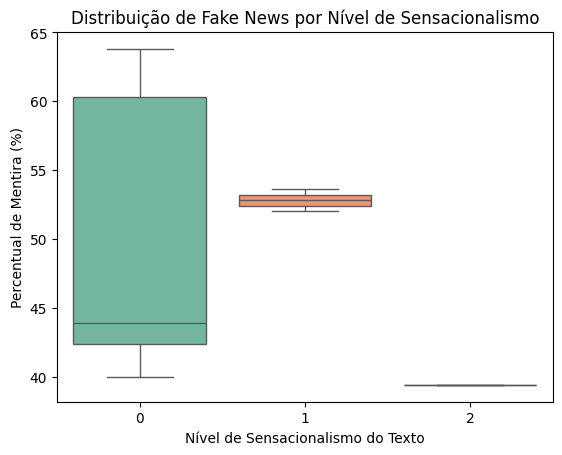

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Limpeza dos dados (Garantir que a porcentagem seja número)
df_selecionado['porcentagem_fake_num'] = df_selecionado['porcentagem_fake'].str.replace('%', '').astype(float)

# 2. Criar o Boxplot usando o Seaborn
# x = a coluna de categorias (sensacionalismo) | y = a coluna de números (porcentagem fake)
sns.boxplot(x='sensacionalismo', y='porcentagem_fake_num', data=df_selecionado, palette='Set2')

# 3. Customizando o gráfico com o Matplotlib
plt.title("Distribuição de Fake News por Nível de Sensacionalismo")
plt.xlabel("Nível de Sensacionalismo do Texto")
plt.ylabel("Percentual de Mentira (%)")

# 4. Mostrar o gráfico na tela
plt.show()


/tmp/ipykernel_512/173982008.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='categoria', y='meta_words_uppercase', data=df_selecionado, palette='Set3')


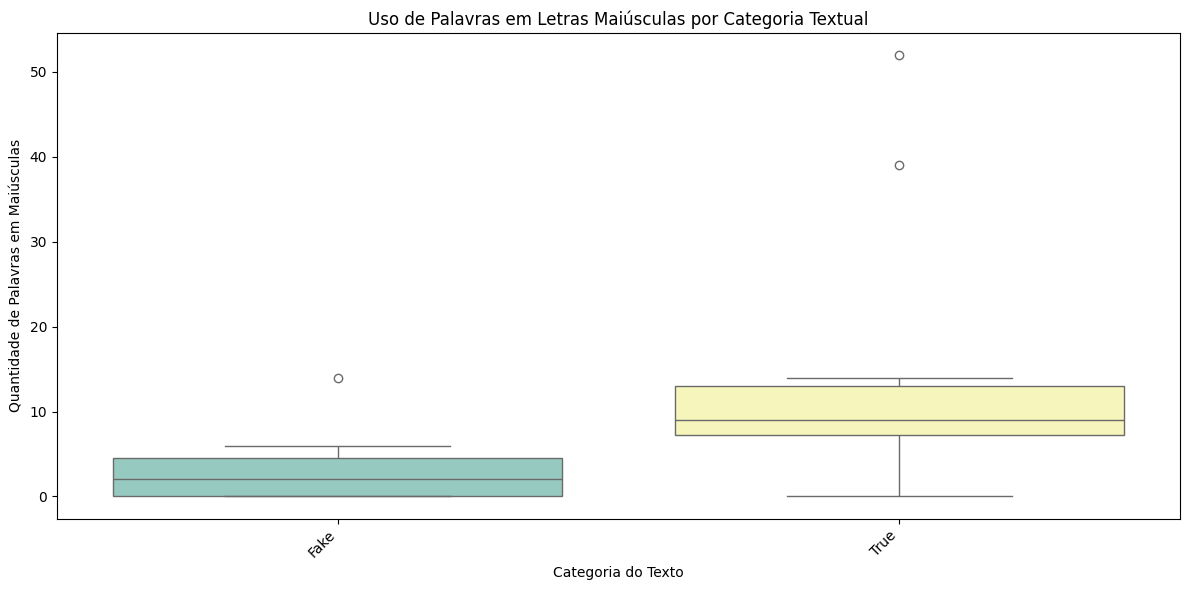

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Configurar o tamanho do gráfico (importante se houver muitas categorias!)
plt.figure(figsize=(12, 6))

# 2. Criar o Boxplot usando o Seaborn
# x = temas/categorias | y = quantidade de palavras em maiúsculo
sns.boxplot(x='categoria', y='meta_words_uppercase', data=df_selecionado, palette='Set3')

# 3. Customizando com o Matplotlib para ficar legível
plt.title("Uso de Palavras em Letras Maiúsculas por Categoria Textual")
plt.xlabel("Categoria do Texto")
plt.ylabel("Quantidade de Palavras em Maiúsculas")

# Dica de ouro: Rotacionar os nomes das categorias para eles não se atropelarem
plt.xticks(rotation=45, ha='right')

# Ajusta o espaçamento para o gráfico não cortar as palavras na parte de baixo
plt.tight_layout()

# 4. Mostrar o gráfico na tela
plt.show()


In [ ]:
print(df_selecionado.columns.tolist())

['texto', 'categoria', 'porcentagem_verdade', 'porcentagem_fake', 'meta_author', 'meta_link', 'meta_category', 'meta_date_pub', 'meta_tokens', 'meta_words_no_punctuation', 'meta_types', 'meta_links_inside', 'meta_words_uppercase', 'meta_verbs', 'meta_subjunctive_imperative_verbs', 'meta_nouns', 'meta_adjectives', 'meta_adverbs', 'meta_pronouns', 'meta_stopwords', 'meta_expressiveness_emotiveness', 'meta_diversity_ttr', 'meta_spelling_errors', 'meta_emotiveness_ratio', 'meta_interrogative_sentences', 'meta_exclamatory_sentences', 'meta_subordinate_sentences', 'meta_vocabulary_richness', 'fontes', 'fonte_identificada', 'sensacionalismo', 'quais_termo_sensacionalistas', 'pontuacao_emotiva', 'quais_frases_emotivas', 'porcentagem_fake_num', 'tipo_noticia']


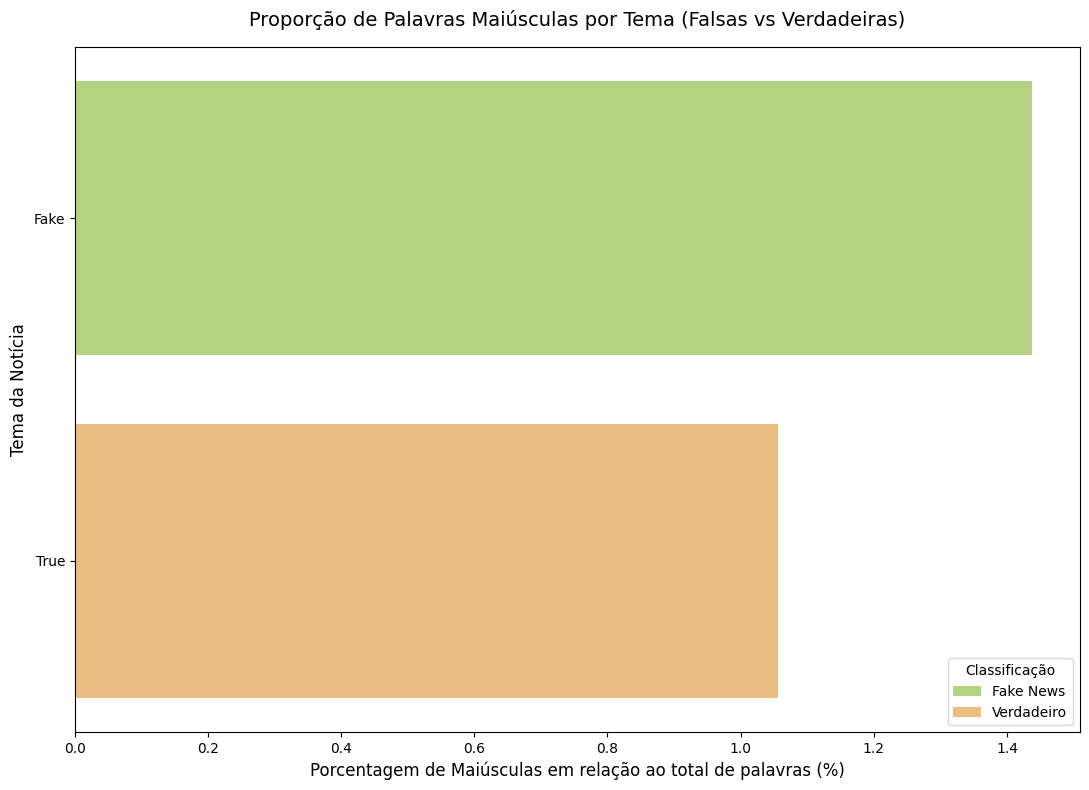

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# =====================================================================
# 1. MAPEAMENTO REAL DAS COLUNAS (Agora com os nomes certos! 🚀)
# =====================================================================
coluna_maiusculas = 'meta_words_uppercase'
coluna_total_palavras = 'meta_words_no_punctuation'  # <-- Corrigido aqui!
coluna_temas = 'categoria'
coluna_fake = 'porcentagem_fake'

# =====================================================================
# 2. LIMPEZA E CRIAÇÃO DAS TAXAS PROPORCIONAIS
# =====================================================================
# Cria a taxa proporcional de maiúsculas em relação ao total de palavras do texto
df_selecionado['porcentagem_maiusculas'] = (df_selecionado[coluna_maiusculas] / df_selecionado[coluna_total_palavras]) * 100

# Limpa o símbolo de '%' da coluna de fake news e transforma em número decimal
df_selecionado['porcentagem_fake_num'] = df_selecionado[coluna_fake].str.replace('%', '').astype(float)

# Cria a classificação definitiva entre Fake News e Verdadeiro
df_selecionado['tipo_noticia'] = df_selecionado['porcentagem_fake_num'].apply(
    lambda x: 'Fake News' if x > 50 else 'Verdadeiro'
)

# =====================================================================
# 3. CONSTRUÇÃO DO GRÁFICO PROFISSIONAL
# =====================================================================
# Define um tamanho grande para o gráfico não amassar as categorias
plt.figure(figsize=(11, 8))

# Desenha as barras horizontais comparando Fake vs Verdadeiro para cada tema
sns.barplot(
    y=coluna_temas,
    x='porcentagem_maiusculas',
    hue='tipo_noticia',
    data=df_selecionado,
    palette='RdYlGn_r', # Vermelho para Fake News, Verde para Verdadeiro
    errorbar=None
)

# Customizações de títulos e eixos
plt.title("Proporção de Palavras Maiúsculas por Tema (Falsas vs Verdadeiras)", fontsize=14, pad=15)
plt.ylabel("Tema da Notícia", fontsize=12)
plt.xlabel("Porcentagem de Maiúsculas em relação ao total de palavras (%)", fontsize=12)
plt.legend(title="Classificação")

# Ajusta o espaçamento para não cortar as legendas nas bordas
plt.tight_layout()

# Exibe o gráfico na tela
plt.show()


proporção ou porcentagem de palavras maiúsculas em relação ao total de palavras do texto

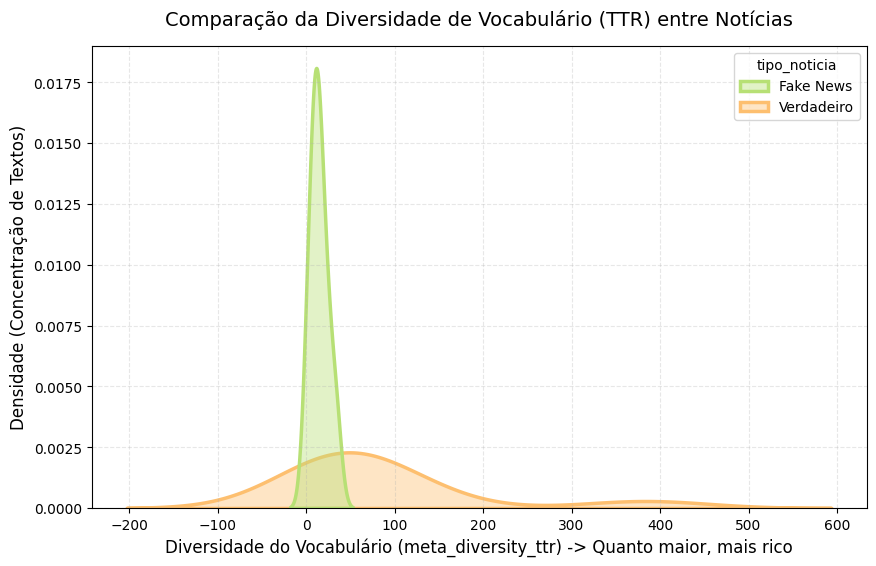

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Definir o tamanho do gráfico
plt.figure(figsize=(10, 6))

# 2. Criar os gráficos de curva sobrepostos usando o 'hue'
# x = a métrica de diversidade de vocabulário | hue = separa as curvas por tipo de notícia
sns.kdeplot(
    x='meta_diversity_ttr',
    hue='tipo_noticia',
    data=df_selecionado,
    fill=True,            # Pinta a área embaixo da curva para ficar fácil de ver
    palette='RdYlGn_r',   # Vermelho para Fake, Verde para Verdadeiro
    alpha=0.4,            # Deixa as curvas transparentes para onde elas se cruzam
    linewidth=2.5         # Deixa a linha da curva um pouco mais grossinha
)

# 3. Customizações profissionais
plt.title("Comparação da Diversidade de Vocabulário (TTR) entre Notícias", fontsize=14, pad=15)
plt.xlabel("Diversidade do Vocabulário (meta_diversity_ttr) -> Quanto maior, mais rico", fontsize=12)
plt.ylabel("Densidade (Concentração de Textos)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.3) # Grade de fundo bem sutil

# 4. Mostrar o gráfico na tela
plt.show()


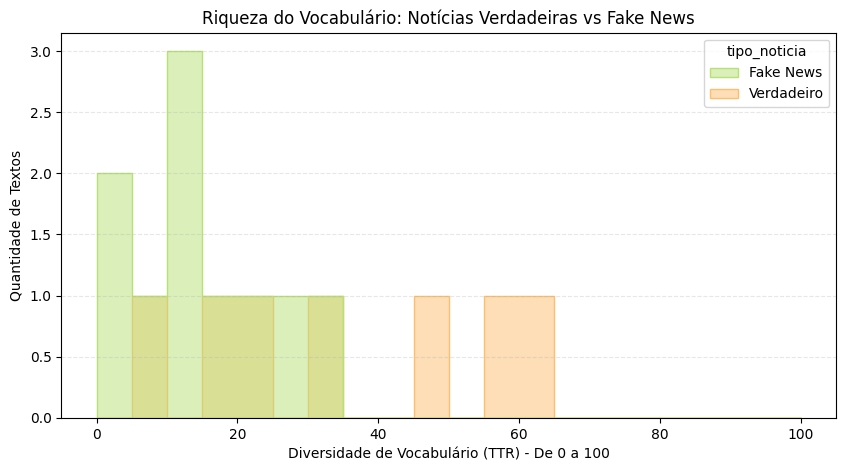

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Definir o tamanho do gráfico
plt.figure(figsize=(10, 5))

# 2. Criar o Histograma (Gráfico de barras coladas)
sns.histplot(
    x='meta_diversity_ttr',
    hue='tipo_noticia',
    data=df_selecionado,
    element='step',       # Deixa o contorno das barras estilo "degraus" (super limpo)
    binrange=(0, 100),    # FOCA APENAS NO REAL: começa no 0 e vai até 100 (sem negativos!)
    bins=20,              # Agrupa os dados em 20 colunas verticais
    palette='RdYlGn_r',   # Vermelho para Fake, Verde para Verdadeiro
    alpha=0.5             # Transparência para ver onde os dados se cruzam
)

# 3. Títulos diretos e simples
plt.title("Riqueza do Vocabulário: Notícias Verdadeiras vs Fake News")
plt.xlabel("Diversidade de Vocabulário (TTR) - De 0 a 100")
plt.ylabel("Quantidade de Textos")
plt.grid(axis='y', linestyle="--", alpha=0.3) # Linhas de grade apenas deitadas

# 4. Mostrar na tela
plt.show()
